# 第 4 章：交通表格型数据分析

本 Notebook 使用英国 STATS19 交通事故开放数据，演示如何把交通事故表格数据整理成可建模数据集，并用逻辑回归、泊松回归、负二项回归和零膨胀模型分析自变量对因变量的影响。

本案例强调“因果导向”的建模思路：先定义因变量和自变量，再说明控制变量、模型解释和局限。这里的模型结果主要用于教学演示，不等同于严格因果识别。

数据源：UK Department for Transport Road Safety Data / STATS19

## 1. 环境准备

```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedPoisson

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "data" / "processed").exists() and (path / "README.md").exists():
            return path
    raise FileNotFoundError("Could not find repository root.")

ROOT = find_repo_root()
DATA_PATH = ROOT / "data" / "processed" / "stats19_collision_casualty_tabular_2023_sample.csv"
DATA_PATH

PosixPath('/home/szu-ciic/桌面/Book/data/processed/stats19_collision_casualty_tabular_2023_sample.csv')

## 2. 读取表格型交通事故数据

每一行是一条交通碰撞记录。数据已经把 STATS19 collision 表和 casualty 表合并，保留了适合教学建模的字段。

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,collision_index,severe_or_fatal,fatal,number_of_casualties,vulnerable_casualties,number_of_vehicles,speed_limit,rural,darkness,adverse_weather,wet_or_icy,junction_present,weekend,road_type_label,light_label,weather_label,surface_label,area_label,longitude,latitude
0,2023010419198,0,0,1,1,1,30,0,1,0,0,0,1,Single carriageway,Darkness - lights lit,Fine no high winds,Dry,Urban,-0.201941,51.545349
1,2023010419205,0,0,1,0,1,50,1,0,0,0,0,1,Dual carriageway,Daylight,Fine no high winds,Dry,Rural,0.072337,51.526805
2,2023010419228,0,0,3,0,2,20,0,1,1,1,1,1,Single carriageway,Darkness - lights lit,Raining no high winds,Wet or damp,Urban,-0.056268,51.539465
3,2023010419263,0,0,1,0,2,20,0,1,1,1,1,1,Single carriageway,Darkness - lights lit,Raining no high winds,Wet or damp,Urban,-0.012912,51.575392
4,2023010419270,0,0,1,0,2,20,0,1,1,1,1,1,Dual carriageway,Darkness - lights lit,Raining no high winds,Wet or damp,Urban,-0.112305,51.481946


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   collision_index        25000 non-null  str    
 1   severe_or_fatal        25000 non-null  int64  
 2   fatal                  25000 non-null  int64  
 3   number_of_casualties   25000 non-null  int64  
 4   vulnerable_casualties  25000 non-null  int64  
 5   number_of_vehicles     25000 non-null  int64  
 6   speed_limit            25000 non-null  int64  
 7   rural                  25000 non-null  int64  
 8   darkness               25000 non-null  int64  
 9   adverse_weather        25000 non-null  int64  
 10  wet_or_icy             25000 non-null  int64  
 11  junction_present       25000 non-null  int64  
 12  weekend                25000 non-null  int64  
 13  road_type_label        25000 non-null  str    
 14  light_label            25000 non-null  str    
 15  weather_label

## 3. 因变量与自变量设计

本案例使用三类因变量：

| 任务 | 因变量 | 模型 | 含义 |
| --- | --- | --- | --- |
| 严重事故概率 | `severe_or_fatal` | 逻辑回归 | 是否为严重或死亡事故 |
| 伤亡人数 | `number_of_casualties` | 泊松/负二项回归 | 一次碰撞造成的伤亡人数 |
| 弱势交通参与者伤亡数 | `vulnerable_casualties` | 零膨胀泊松 | 行人或骑行者伤亡数 |

主要自变量包括：速度限制、城乡属性、照明、天气、路面、路口、周末和车辆数。

In [4]:
outcomes = ["severe_or_fatal", "number_of_casualties", "vulnerable_casualties"]
predictors = ["speed_limit", "rural", "darkness", "adverse_weather", "wet_or_icy", "junction_present", "weekend", "number_of_vehicles"]

df[outcomes + predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
severe_or_fatal,25000.0,0.23720,0.425374,0.0,0.0,0.0,0.0,1.0
number_of_casualties,25000.0,1.27976,0.834172,1.0,1.0,1.0,1.0,70.0
vulnerable_casualties,25000.0,0.32560,0.495494,0.0,0.0,0.0,1.0,11.0
speed_limit,25000.0,35.83680,14.320753,20.0,30.0,30.0,40.0,70.0
rural,25000.0,0.32400,0.468009,0.0,0.0,0.0,1.0,1.0
darkness,25000.0,0.28864,0.453139,0.0,0.0,0.0,1.0,1.0
adverse_weather,25000.0,0.17100,0.376516,0.0,0.0,0.0,0.0,1.0
wet_or_icy,25000.0,0.27440,0.446220,0.0,0.0,0.0,1.0,1.0
junction_present,25000.0,0.46528,0.498803,0.0,0.0,0.0,1.0,1.0
weekend,25000.0,0.24624,0.430829,0.0,0.0,0.0,0.0,1.0


## 4. 描述性可视化

先用图表理解变量和结果的关系，再进入模型。

,speed_limit,severe_rate,n
0,20,0.190279,4341
1,30,0.224871,12963
2,40,0.259362,2163
3,50,0.276224,1144
4,60,0.335068,3074
5,70,0.214449,1315


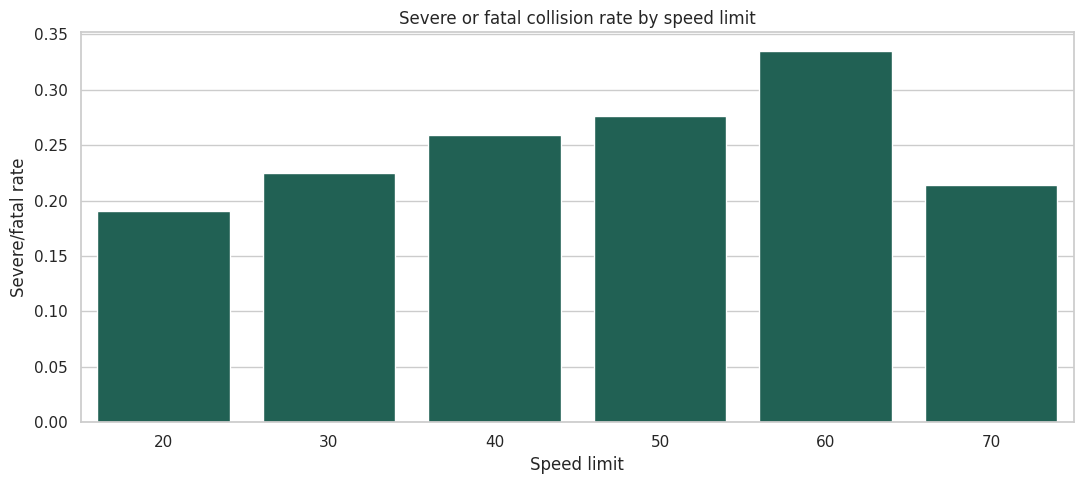

In [5]:
severity_by_speed = (
    df.groupby("speed_limit", as_index=False)
    .agg(severe_rate=("severe_or_fatal", "mean"), n=("severe_or_fatal", "size"))
)

ax = sns.barplot(data=severity_by_speed, x="speed_limit", y="severe_rate", color="#176b5b")
ax.set_title("Severe or fatal collision rate by speed limit")
ax.set_xlabel("Speed limit")
ax.set_ylabel("Severe/fatal rate")
plt.tight_layout()
severity_by_speed

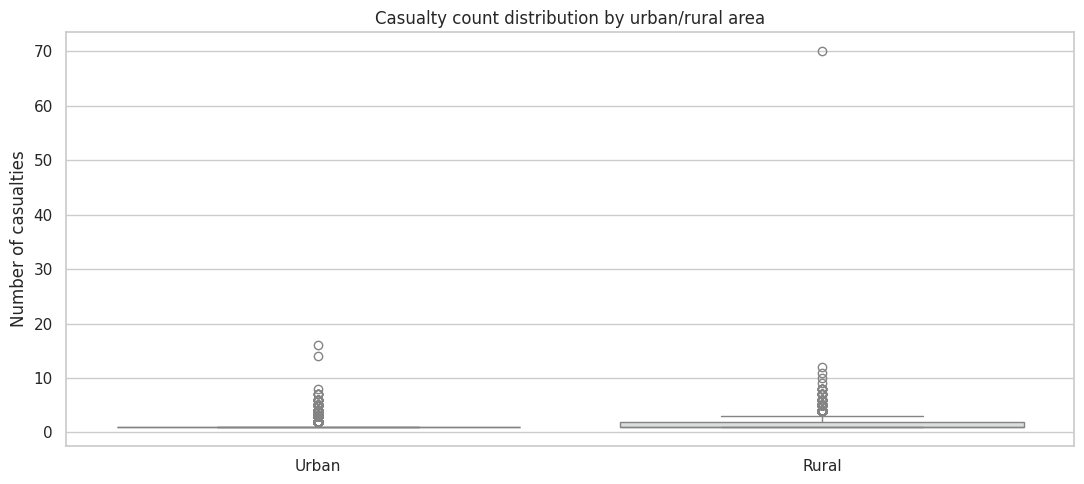

In [6]:
ax = sns.boxplot(data=df, x="area_label", y="number_of_casualties", color="#d9e0dc")
ax.set_title("Casualty count distribution by urban/rural area")
ax.set_xlabel("")
ax.set_ylabel("Number of casualties")
plt.tight_layout()

Share of observations with zero vulnerable road-user casualties: 68.4%


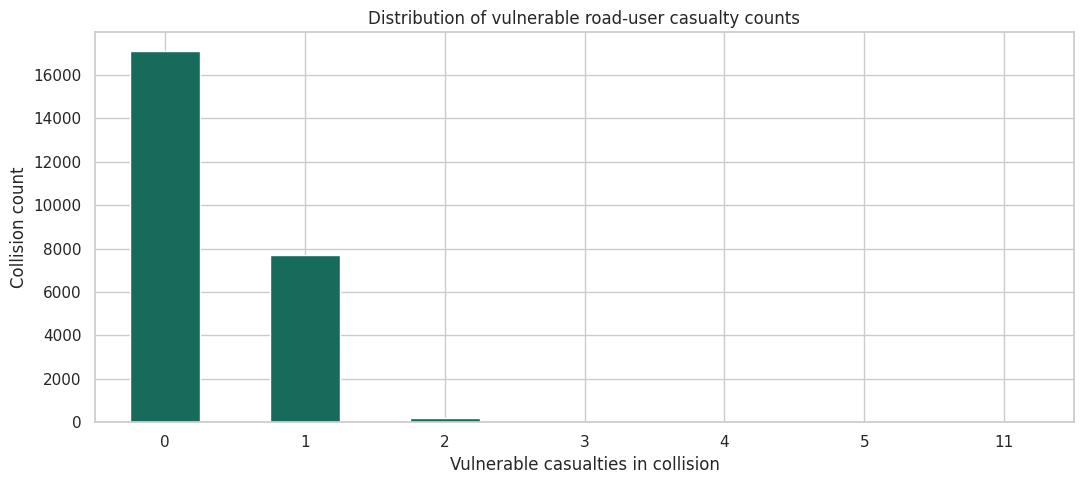

In [7]:
zero_share = (df["vulnerable_casualties"] == 0).mean()
print(f"Share of observations with zero vulnerable road-user casualties: {zero_share:.1%}")

ax = df["vulnerable_casualties"].value_counts().sort_index().plot(kind="bar", color="#176b5b")
ax.set_title("Distribution of vulnerable road-user casualty counts")
ax.set_xlabel("Vulnerable casualties in collision")
ax.set_ylabel("Collision count")
plt.xticks(rotation=0)
plt.tight_layout()

## 5. 逻辑回归：自变量对严重事故概率的影响

因变量：`severe_or_fatal`。

核心解释：`np.exp(coef)` 是 odds ratio。大于 1 表示严重/死亡事故的优势比增加，小于 1 表示降低。

In [8]:
logit_formula = "severe_or_fatal ~ speed_limit + rural + darkness + adverse_weather + wet_or_icy + junction_present + weekend + number_of_vehicles"
logit_model = smf.logit(logit_formula, data=df).fit(disp=False, maxiter=200)

logit_results = pd.DataFrame({
    "coef": logit_model.params,
    "odds_ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues,
})
logit_results

,coef,odds_ratio,p_value
Intercept,-1.236353,0.290442,9.259851e-82
speed_limit,0.008223,1.008257,7.912128e-09
rural,0.213199,1.237631,9.517324e-07
darkness,0.188434,1.207358,1.896645e-08
adverse_weather,-0.136525,0.872385,7.050666e-03
wet_or_icy,0.019470,1.019661,6.500384e-01
junction_present,0.056534,1.058163,7.481714e-02
weekend,0.158671,1.171952,3.202859e-06
number_of_vehicles,-0.227795,0.796288,1.271915e-22


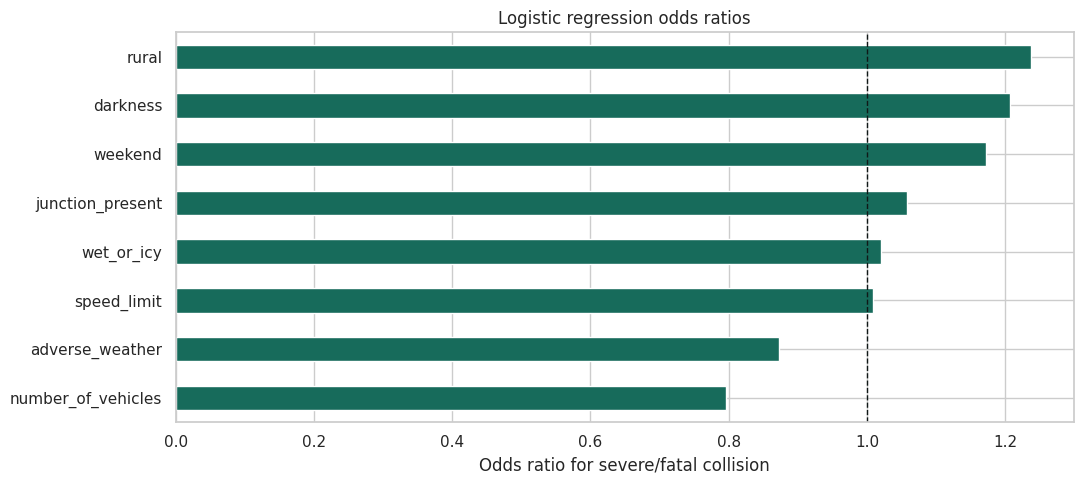

In [9]:
logit_plot = logit_results.drop(index="Intercept").sort_values("odds_ratio")
ax = logit_plot["odds_ratio"].plot(kind="barh", color="#176b5b")
ax.axvline(1, color="#101817", linestyle="--", linewidth=1)
ax.set_title("Logistic regression odds ratios")
ax.set_xlabel("Odds ratio for severe/fatal collision")
plt.tight_layout()

## 6. 泊松回归：伤亡人数计数模型

因变量：`number_of_casualties`。

泊松回归适合计数数据，但有均值等于方差的假设。我们会计算离散统计量来检查这个假设。

In [10]:
count_formula = "number_of_casualties ~ speed_limit + rural + darkness + adverse_weather + wet_or_icy + junction_present + weekend + number_of_vehicles"
poisson_model = smf.glm(count_formula, data=df, family=sm.families.Poisson()).fit()
poisson_results = pd.DataFrame({
    "coef": poisson_model.params,
    "incidence_rate_ratio": np.exp(poisson_model.params),
    "p_value": poisson_model.pvalues,
})
poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Poisson AIC: {poisson_model.aic:.2f}")
print(f"Dispersion statistic: {poisson_dispersion:.2f}")
poisson_results

Poisson AIC: 60156.54
Dispersion statistic: 0.45


,coef,incidence_rate_ratio,p_value
Intercept,-0.251598,0.777557,1.711485e-28
speed_limit,0.004456,1.004466,4.514376e-17
rural,0.075225,1.078126,3.943448e-06
darkness,0.041355,1.042222,1.080790e-03
adverse_weather,-0.010033,0.990017,5.921996e-01
wet_or_icy,0.027426,1.027805,8.699513e-02
junction_present,0.034000,1.034585,4.001867e-03
weekend,0.063615,1.065682,6.695449e-07
number_of_vehicles,0.139215,1.149371,1.574466e-94


## 7. 负二项回归：泊松模型的替代方案

负二项回归放宽泊松回归对方差结构的要求。实际案例中，如果计数数据过度离散，负二项模型经常更合适。

在本教学样本中，AIC 比较只是模型比较练习，结论要结合离散统计量解释。

In [11]:
negative_binomial_model = smf.glm(
    count_formula,
    data=df,
    family=sm.families.NegativeBinomial(),
).fit()

model_comparison = pd.DataFrame({
    "model": ["Poisson", "Negative Binomial"],
    "aic": [poisson_model.aic, negative_binomial_model.aic],
    "bic": [poisson_model.bic, negative_binomial_model.bic],
})
model_comparison

/home/szu-ciic/桌面/Book/.python-user/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/szu-ciic/桌面/Book/.python-user/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,model,aic,bic
0,Poisson,60156.537885,-246528.717588
1,Negative Binomial,77853.312267,-250762.566668


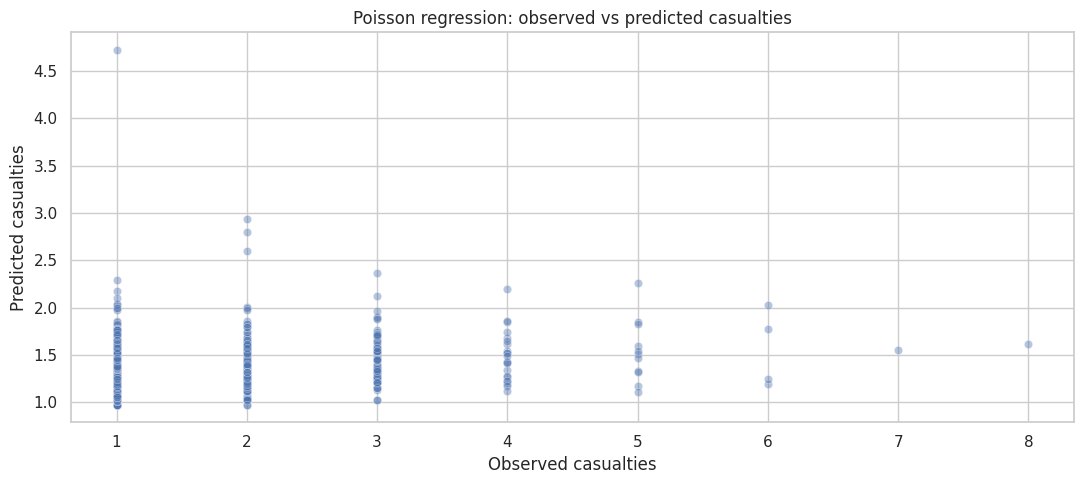

In [12]:
df["poisson_predicted_casualties"] = poisson_model.predict(df)

ax = sns.scatterplot(data=df.sample(2000, random_state=7), x="number_of_casualties", y="poisson_predicted_casualties", alpha=0.4)
ax.set_title("Poisson regression: observed vs predicted casualties")
ax.set_xlabel("Observed casualties")
ax.set_ylabel("Predicted casualties")
plt.tight_layout()

## 8. 零膨胀泊松：弱势交通参与者伤亡数

因变量：`vulnerable_casualties`。很多碰撞没有行人或骑行者伤亡，因此零值比例较高。零膨胀模型把“是否处于结构性零值状态”和“非结构性零值下的计数过程”分开。

In [13]:
zip_exog = sm.add_constant(df[predictors].astype(float))
zip_infl = sm.add_constant(df[["rural", "darkness", "junction_present"]].astype(float))

zip_model = ZeroInflatedPoisson(
    endog=df["vulnerable_casualties"],
    exog=zip_exog,
    exog_infl=zip_infl,
).fit(disp=False, maxiter=200)

zip_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      ZeroInflatedPoisson Regression Results                     
=================================================================================
Dep. Variable:     vulnerable_casualties   No. Observations:                25000
Model:               ZeroInflatedPoisson   Df Residuals:                    24991
Method:                              MLE   Df Model:                            8
Date:                   Wed, 29 Apr 2026   Pseudo R-squ.:                  0.1348
Time:                           18:04:12   Log-Likelihood:                -15111.
converged:                          True   LL-Null:                       -17466.
Covariance Type:               nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
inflate_const              -14.7546     53.339     -0.277      0.782    -119.297      89.788
inflate_rural                1.0343    107.798      0.010      0.992    -210.246     212.315
inflate_darkness            -2.3983    435.904     -0.006      0.996    -856.754     851.957
inflate_junction_present    -6.4044   1016.312     -0.006      0.995   -1998.338    1985.530
const                        1.7611      0.052     33.558      0.000       1.658       1.864
speed_limit                 -0.0371      0.001    -25.927      0.000      -0.040      -0.034
rural                       -0.3502      0.038     -9.314      0.000      -0.424      -0.277
darkness                    -0.1384      0.026     -5.327      0.000      -0.189      -0.087
adverse_weather             -0.0671      0.039     -1.726      0.084      -0.143       0.009
wet_or_icy                  -0.0904      0.034     -2.686      0.007      -0.156      -0.024
junction_present             0.0846      0.023      3.707      0.000       0.040       0.129
weekend                     -0.1357      0.027     -5.007      0.000      -0.189      -0.083
number_of_vehicles          -0.9501      0.021    -45.799      0.000      -0.991      -0.909
============================================================================================
"""

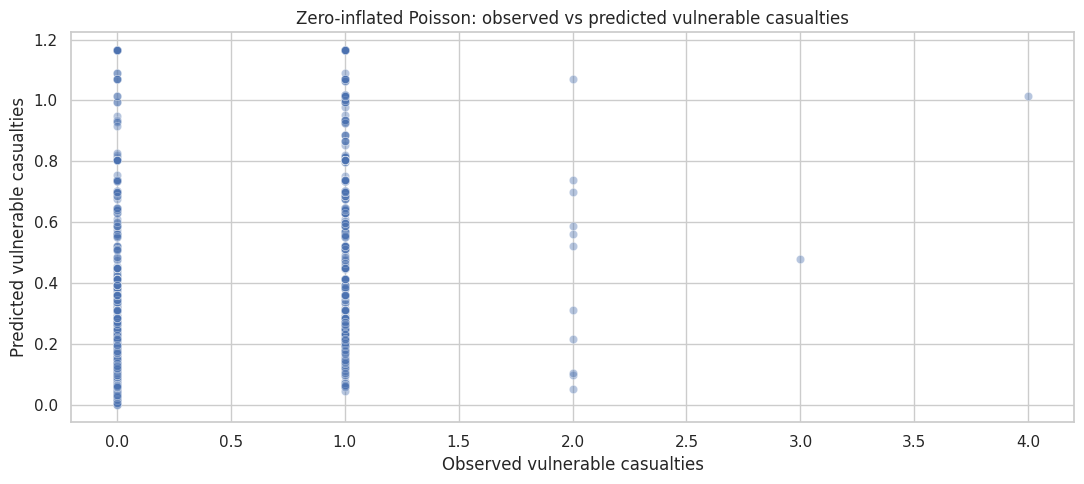

In [14]:
df["zip_predicted_vulnerable_casualties"] = zip_model.predict(exog=zip_exog, exog_infl=zip_infl)

ax = sns.scatterplot(
    data=df.sample(2000, random_state=8),
    x="vulnerable_casualties",
    y="zip_predicted_vulnerable_casualties",
    alpha=0.4,
)
ax.set_title("Zero-inflated Poisson: observed vs predicted vulnerable casualties")
ax.set_xlabel("Observed vulnerable casualties")
ax.set_ylabel("Predicted vulnerable casualties")
plt.tight_layout()

## 9. 因果分析解释边界

本案例采用因果导向的语言：自变量、因变量、控制变量、暴露/处理因素。但它仍然不是严格因果识别。

更严格的因果分析需要：

- 明确处理变量，例如速度限制变化、照明改善、道路改造。
- 明确混杂变量，例如交通流量、道路等级、地区人口、天气暴露、执法强度。
- 使用更合适的识别策略，例如匹配、倾向得分、双重差分、断点回归或面板固定效应。
- 避免把相关性回归直接解释为政策效果。

## 10. 学生任务

### 基础任务

1. 读取表格数据并解释每个因变量。
2. 比较不同速度限制下的严重事故比例。
3. 绘制弱势交通参与者伤亡数的零值分布。

### 进阶任务

1. 拟合逻辑回归并解释一个 odds ratio。
2. 拟合泊松回归并解释一个 incidence rate ratio。
3. 比较泊松回归和负二项回归。

### 挑战任务

1. 拟合零膨胀泊松模型并解释两个部分。
2. 选择一个自变量，写出可能的混杂因素。
3. 设计一个更接近因果识别的研究方案。